# Title and objective

# Deep Learning Based Text Topic Classification

## Objective

The objective of this project is to build a Deep Learning NLP model
that classifies text documents into different topic categories.

The text data is converted into numerical features using TF-IDF
and then given to a neural network built using TensorFlow/Keras.

The model uses:
- TF-IDF vectorization
- Dense neural network layers
- Batch Normalization
- Dropout
- Early Stopping

The final model is evaluated using accuracy, classification report,
confusion matrix, training curves, and unseen text predictions
with classification confidence.

# Import libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# Load the dataset

In [5]:
categories = [
    "rec.sport.baseball",
    "sci.space",
    "comp.graphics",
    "talk.politics.misc"
]

train_data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

test_data = fetch_20newsgroups(
    subset="test",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

print("Training samples:", len(train_data.data))
print("Testing samples:", len(test_data.data))
print("Categories:", train_data.target_names)

Training samples: 2239
Testing samples: 1490
Categories: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']


# Create DataFrames

In [6]:
train_df = pd.DataFrame({
    "text": train_data.data,
    "target": train_data.target
})

test_df = pd.DataFrame({
    "text": test_data.data,
    "target": test_data.target
})

train_df.head()

,text,target
0,I thought that was Sandy Koufax.,1
1,"\nAnd the religious right worships engines, sm...",3
2,\nHow can a witness tell that someone in a bur...,3
3,"\n\n\n\nYes, long before Star Trek. Before Ei...",2
4,\n\nIt depends. If you can get your old veter...,1


### Check the dataset

In [7]:
print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

print("\nClass distribution:")
print(train_df["target"].value_counts().sort_index())

Training dataset shape: (2239, 2)
Testing dataset shape: (1490, 2)

Class distribution:
target
0    584
1    597
2    593
3    465
Name: count, dtype: int64


# Convert target numbers to topic names

In [8]:
label_mapping = {
    index: name
    for index, name in enumerate(train_data.target_names)
}

train_df["topic"] = train_df["target"].map(label_mapping)
test_df["topic"] = test_df["target"].map(label_mapping)

train_df[["text", "topic"]].head()

,text,topic
0,I thought that was Sandy Koufax.,rec.sport.baseball
1,"\nAnd the religious right worships engines, sm...",talk.politics.misc
2,\nHow can a witness tell that someone in a bur...,talk.politics.misc
3,"\n\n\n\nYes, long before Star Trek. Before Ei...",sci.space
4,\n\nIt depends. If you can get your old veter...,rec.sport.baseball


## Check for missing values

In [9]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in testing data:")
print(test_df.isnull().sum())

Missing values in training data:
text      0
target    0
topic     0
dtype: int64

Missing values in testing data:
text      0
target    0
topic     0
dtype: int64


In [10]:
train_df = train_df[train_df["text"].str.strip() != ""].copy()
test_df = test_df[test_df["text"].str.strip() != ""].copy()

print("Training samples after cleaning:", len(train_df))
print("Testing samples after cleaning:", len(test_df))

Training samples after cleaning: 2176
Testing samples after cleaning: 1448


# Prepare X and y

In [12]:
X_train_full = train_df["text"]
y_train_full = train_df["target"]

X_test = test_df["text"]
y_test = test_df["target"]

print("X_train:", X_train_full.shape)
print("y_train:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2176,)
y_train: (2176,)
X_test: (1448,)
y_test: (1448,)


# Create validation data

#### We already have a separate test dataset.

#### Now we'll split the training data into:

- Training       → 80%
- Validation     → 20%

#### Separate test dataset → final evaluation

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 1740
Validation samples: 436
Test samples: 1448


#### Why do we need validation data?

- The model learns from the training data.

- Validation data helps us monitor whether the model is generalizing well while training.

- The test data is kept separate and used only at the end for final evaluation.

# TF-IDF Vectorization

- This is one of the most important parts of the NLP pipeline.

- A neural network cannot directly understand:

- "The spacecraft successfully entered orbit."

- We need to convert the text into numbers.

- TF-IDF does that.

In [15]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1740, 10000)
Validation TF-IDF shape: (436, 10000)
Testing TF-IDF shape: (1448, 10000)


# Convert TF-IDF data to arrays

##### TensorFlow can work with dense numerical arrays.

In [16]:
X_train_array = X_train_tfidf.toarray()
X_val_array = X_val_tfidf.toarray()
X_test_array = X_test_tfidf.toarray()

print("Input features:", X_train_array.shape[1])

Input features: 10000


# Build the Deep Learning model

In [19]:
from tensorflow.keras import Input

input_features = X_train_array.shape[1]
num_classes = len(np.unique(y_train))

model = Sequential([
    Input(shape=(input_features,)),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,204 (9.93 MB)

 Trainable params: 2,602,436 (9.93 MB)

 Non-trainable params: 768 (3.00 KB)

# Compile the model

In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


# Early Stopping

In [22]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

#### Why?

##### Suppose validation loss behaves like:

- Epoch 1 → 1.20
- Epoch 2 → 0.90
- Epoch 3 → 0.70
- Epoch 4 → 0.65
- Epoch 5 → 0.67
- Epoch 6 → 0.71
- Epoch 7 → 0.75

##### The model is no longer improving on validation data.

##### Early stopping prevents unnecessary training and helps reduce overfitting.

# Train the model

In [24]:
history = model.fit(
    X_train_array,
    y_train,
    validation_data=(X_val_array, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9897 - loss: 0.0308 - val_accuracy: 0.8899 - val_loss: 0.3347
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9891 - loss: 0.0320 - val_accuracy: 0.8830 - val_loss: 0.3350
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9891 - loss: 0.0329 - val_accuracy: 0.8807 - val_loss: 0.3297


# Plot training curves

##### Accuracy

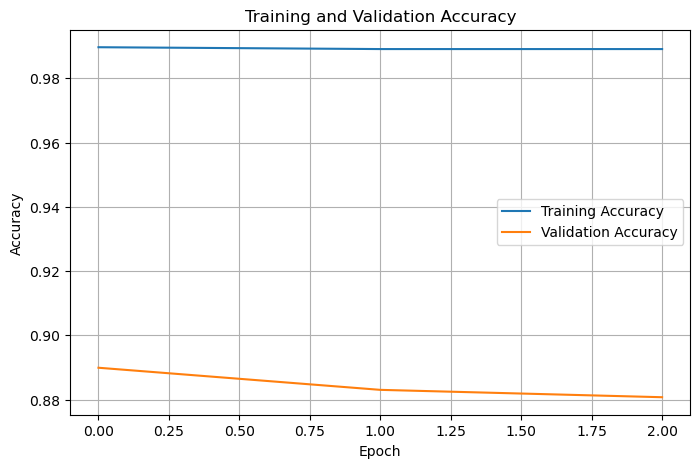

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

##### Loss

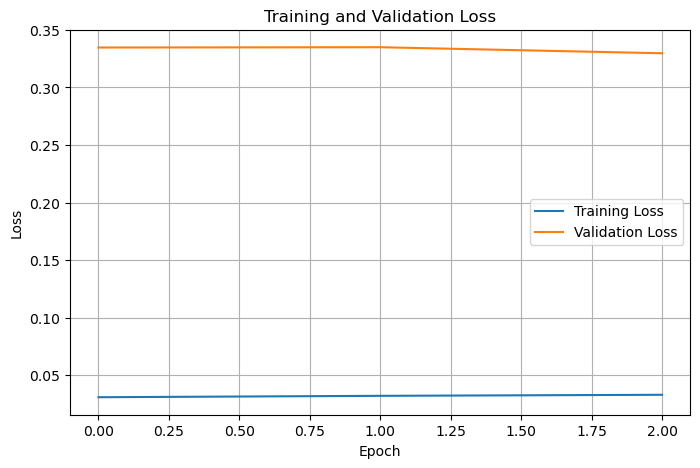

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the model

In [27]:
test_loss, test_accuracy = model.evaluate(
    X_test_array,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.4819
Test Accuracy: 0.8515


# Classification Report

In [28]:
y_pred_prob = model.predict(X_test_array, verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=train_data.target_names
    )
)

                    precision    recall  f1-score   support

     comp.graphics       0.93      0.89      0.91       384
rec.sport.baseball       0.89      0.87      0.88       383
         sci.space       0.89      0.77      0.82       378
talk.politics.misc       0.71      0.88      0.79       303

          accuracy                           0.85      1448
         macro avg       0.85      0.85      0.85      1448
      weighted avg       0.86      0.85      0.85      1448



# Confusion Matrix

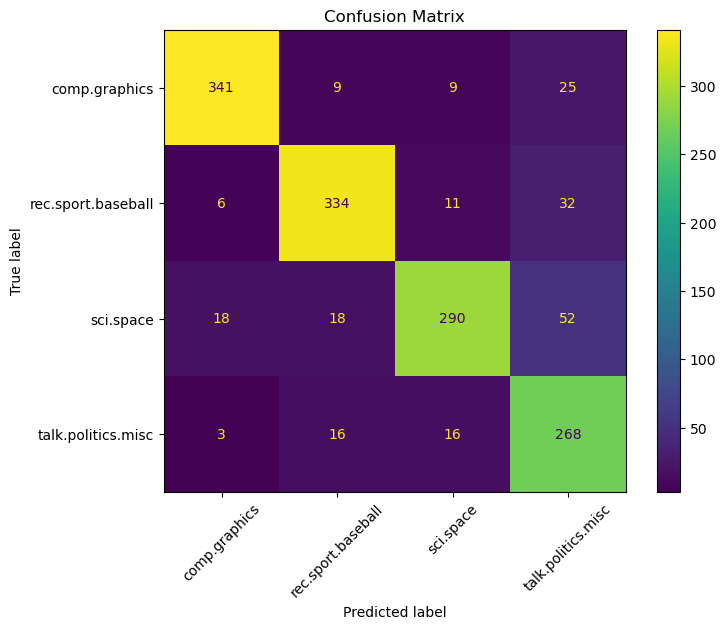

In [29]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.target_names
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

# Test unseen text

In [30]:
sample_texts = [
    "The baseball team won the game after scoring three runs in the final inning.",
    "NASA is preparing a new spacecraft for a mission to explore Mars.",
    "The computer graphics program can render realistic three dimensional images.",
    "The government announced a new policy during the political debate."
]

sample_tfidf = tfidf.transform(sample_texts).toarray()

sample_probabilities = model.predict(sample_tfidf, verbose=0)

predicted_classes = np.argmax(sample_probabilities, axis=1)

for text, predicted_class, probabilities in zip(
    sample_texts,
    predicted_classes,
    sample_probabilities
):
    topic = train_data.target_names[predicted_class]
    confidence = probabilities[predicted_class] * 100

    print("Text:", text)
    print("Predicted Topic:", topic)
    print("Confidence:", round(confidence, 2), "%")
    print("-" * 80)

Text: The baseball team won the game after scoring three runs in the final inning.
Predicted Topic: rec.sport.baseball
Confidence: 100.0 %
--------------------------------------------------------------------------------
Text: NASA is preparing a new spacecraft for a mission to explore Mars.
Predicted Topic: sci.space
Confidence: 99.44 %
--------------------------------------------------------------------------------
Text: The computer graphics program can render realistic three dimensional images.
Predicted Topic: comp.graphics
Confidence: 99.99 %
--------------------------------------------------------------------------------
Text: The government announced a new policy during the political debate.
Predicted Topic: talk.politics.misc
Confidence: 99.67 %
--------------------------------------------------------------------------------


# Create a clean prediction function

In [31]:
def predict_topic(text):
    text_tfidf = tfidf.transform([text]).toarray()

    probabilities = model.predict(
        text_tfidf,
        verbose=0
    )[0]

    predicted_index = np.argmax(probabilities)

    predicted_topic = train_data.target_names[predicted_index]
    confidence = probabilities[predicted_index] * 100

    return predicted_topic, confidence

In [32]:
text = "The spacecraft successfully entered orbit around the planet."

topic, confidence = predict_topic(text)

print("Input Text:", text)
print("Predicted Topic:", topic)
print("Confidence:", round(confidence, 2), "%")

Input Text: The spacecraft successfully entered orbit around the planet.
Predicted Topic: sci.space
Confidence: 99.84 %


# Final conclusion

- In this project, a Deep Learning based NLP text classification pipeline was developed to classify documents into different topics.

- The text data was converted into numerical features using TF-IDF.
- A multi-layer neural network was then trained using TensorFlow/Keras.

- The model included Batch Normalization and Dropout to improve
- training stability and reduce overfitting. Early Stopping was used to stop training when validation performance stopped improving.

- The model was evaluated using test accuracy, classification report, and confusion matrix. Finally, unseen text samples were provided to the model and the predicted topic along with classification confidence was displayed.

- This project demonstrates the complete pipeline from text preprocessing and feature extraction to Deep Learning based classification and inference.